In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("AmesHousing.csv")

# Inspect structure and data types
df.head()
df.info()

# Select relevant columns for analysis
df2 = df[[
    "SalePrice",
    "Gr Liv Area",
    "Overall Qual",
    "Year Built",
    "Total Bsmt SF",
    "Lot Area",
    "Overall Cond",
    "Full Bath",
    "Garage Cars",
    "TotRms AbvGrd",
    "Year Remod/Add",
    "Neighborhood"
]]
df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

,SalePrice,Gr Liv Area,Overall Qual,Year Built,Total Bsmt SF,Lot Area,Overall Cond,Full Bath,Garage Cars,TotRms AbvGrd,Year Remod/Add,Neighborhood
0,215000,1656,6,1960,1080.0,31770,5,1,2.0,7,1960,NAmes
1,105000,896,5,1961,882.0,11622,6,1,1.0,5,1961,NAmes
2,172000,1329,6,1958,1329.0,14267,6,1,1.0,6,1958,NAmes
3,244000,2110,7,1968,2110.0,11160,5,2,2.0,8,1968,NAmes
4,189900,1629,5,1997,928.0,13830,5,2,2.0,6,1998,Gilbert


Text(0, 0.5, 'Sale Price')

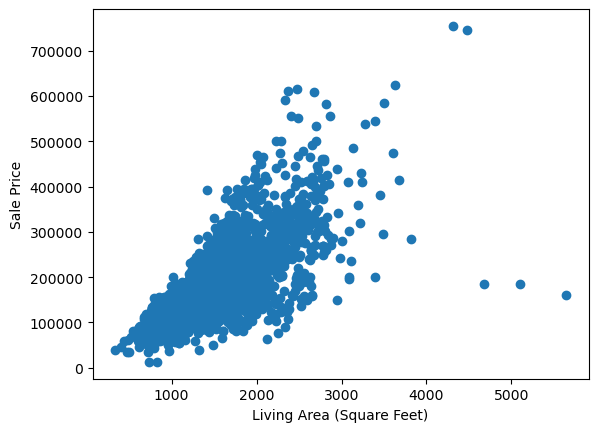

In [15]:
# Scatter plot of living area vs sale price to analyze how home size impacts price.
# The plot shows a strong positive relationship, where larger homes tend to have higher prices,
# although variability increases for very large homes and some outliers are present.
plt.scatter(df2["Gr Liv Area"],df2["SalePrice"])
plt.xlabel("Living Area (Square Feet)")
plt.ylabel("Sale Price")

Text(0, 0.5, 'Sale Price')

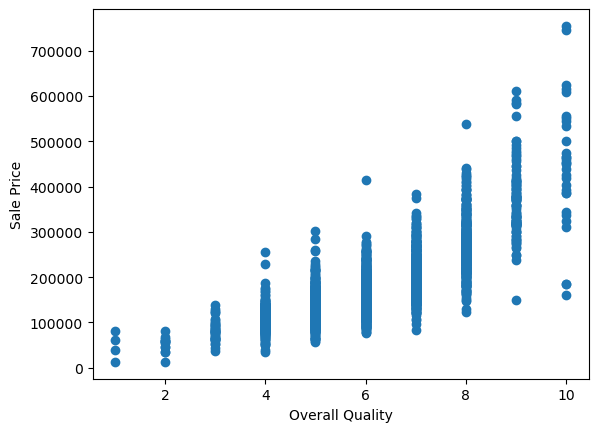

In [4]:
# Scatter plot of overall quality vs sale price to examine how quality affects pricing.
# The plot shows a strong positive relationship with clear price tiers, indicating that higher
# quality ratings significantly increase home value, though there is still variance within each level.
plt.scatter(df2["Overall Qual"],df2["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

Text(0, 0.5, 'Sale Price')

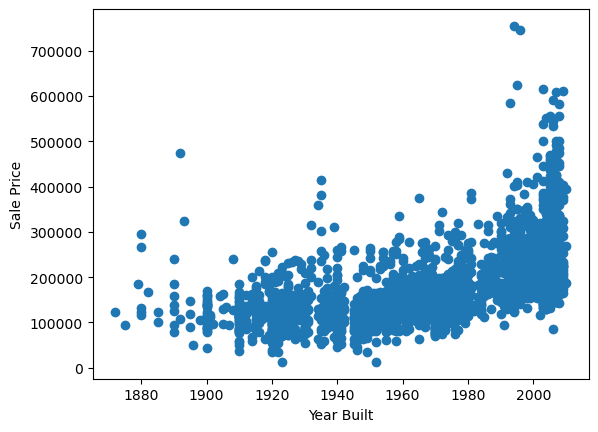

In [5]:
# Scatter plot of Year Built vs SalePrice to examine how house age relates to price.
# The plot shows a weak positive relationship, with newer homes generally priced higher,
# but significant variation indicates that age alone is not a strong predictor of price.
plt.scatter(df2["Year Built"],df2["SalePrice"])
plt.xlabel("Year Built")
plt.ylabel("Sale Price")

In [6]:
print(df2["Gr Liv Area"].corr(df2["SalePrice"]))
print(df2["Overall Qual"].corr(df2["SalePrice"]))
print(df2["Year Built"].corr(df2["SalePrice"]))
print(df2["Total Bsmt SF"].corr(df2["SalePrice"]))

0.7067799209766279
0.7992617947690227
0.5584261057120454
0.6322804571065125


In [7]:
# Select features (size, quality)
X = df2[["Gr Liv Area", "Overall Qual"]]

# Target variable (house price)
y = df2["SalePrice"]

# Train linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

# Generate predictions
predictions = model.predict(X)

# Compare predicted and actual house price values
df_compare = df2.copy()
df_compare["Predicted"] = predictions
df_compare[["SalePrice", "Predicted"]].head(10)

[186825.91379237 108931.45310485 167613.34691717 ... 113279.2511133
 137897.1884855  240278.69918911]


,SalePrice,Predicted
0,215000,186825.913792
1,105000,108931.453105
2,172000,167613.346917
3,244000,246741.642175
4,189900,151998.154999
5,195500,183770.704381
6,213500,234624.933282
7,191500,231217.199708
8,236500,250958.552827
9,189000,228762.909869


In [8]:
df2.isnull().sum()
df2 = df2.copy()
df2["Total Bsmt SF"] = df2["Total Bsmt SF"].fillna(0)

In [12]:
# Select features (size, quality, basement space)
X = df2[["Gr Liv Area", "Overall Qual", "Total Bsmt SF"]]

# Target variable (house price)
y = df2["SalePrice"]

# Train linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

# Generate predictions
predictions = model.predict(X)

# Compare predicted and actual house price values
df_compare = df2.copy()
df_compare["Predicted"] = predictions
df_compare[["SalePrice", "Predicted"]].head(10)

,SalePrice,Predicted
0,215000,187406.834320
1,105000,112188.601711
2,172000,180121.303839
3,244000,279225.571438
4,189900,152139.868747
5,195500,178679.433148
6,213500,236779.647004
7,191500,231493.162047
8,236500,261297.299874
9,189000,219667.030338
